<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-excersises./blob/main/Digital_Art_History_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install DVT and Google Vision
!pip install dvt google-cloud-vision

import os
import io
import dvt
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from google.cloud import vision

# 1. Set credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

Success: Image file downloaded.

--- Displaying Stagecoach (1939) ---


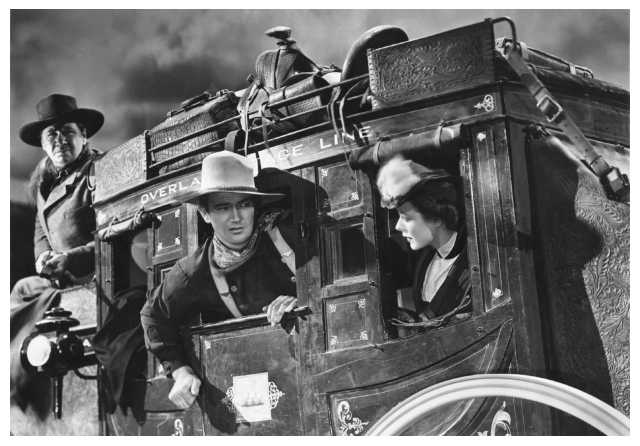


Google Vision Identifications:
- Hat (97.75% confidence)
- Sun hat (91.82% confidence)
- Black (90.63% confidence)
- Monochrome photography (88.48% confidence)
- Black and white (83.93% confidence)
- Monochrome (83.11% confidence)
- Fedora (80.59% confidence)
- Cowboy hat (77.37% confidence)
- Vintage clothing (67.54% confidence)
- Retro style (59.89% confidence)


In [ ]:
import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def process_and_identify(image_url):
    local_filename = "stagecoach_final.jpg"

    # 3. FIX: Mimic a browser to avoid 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Accept': 'image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=15)
        response.raise_for_status()

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image file downloaded.")

    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    # dvt.load_image will now find actual pixel data
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(8, 6))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Identify with Google Vision
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    vision_response = client.label_detection(image=image)
    labels = vision_response.label_annotations

    print("\nGoogle Vision Identifications:")
    for label in labels:
        print(f"- {label.description} ({label.score:.2%} confidence)")

# 6. RUN WITH THE CORRECT DIRECT URL
# This link points to the actual .jpg file, not the website
stagecoach_direct_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"
process_and_identify(stagecoach_direct_url)

Success: Image downloaded for analysis.

--- Displaying Stagecoach (1939) ---


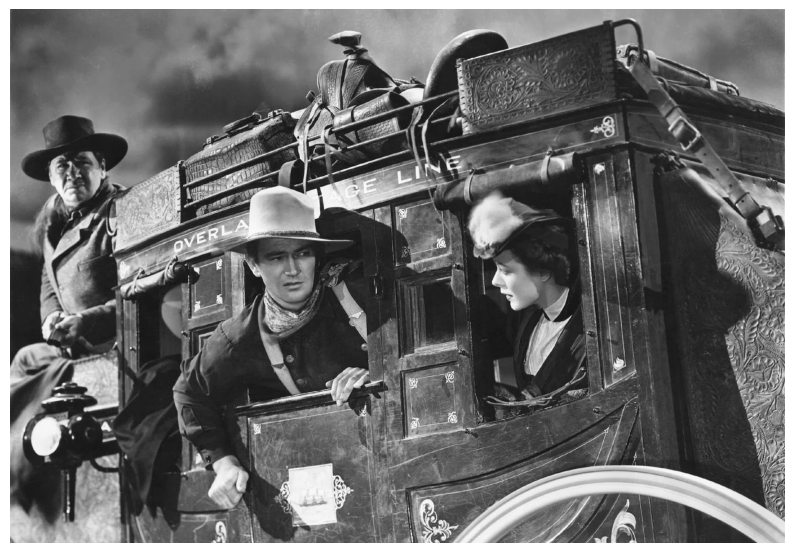

Detected 3 face(s):

--- Person #1 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: UNLIKELY

--- Person #2 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: VERY_LIKELY

--- Person #3 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: VERY_LIKELY


In [ ]:
import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
# Ensure 'renaissance-ocr-4aabe5b8dc65.json' is uploaded to the /content/ folder
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def analyze_stagecoach_faces(image_url):
    local_filename = "stagecoach_analysis.jpg"

    # 3. Comprehensive headers to bypass 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.9',
        'Referer': 'https://commons.wikimedia.org'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=20)
        response.raise_for_status()

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image downloaded for analysis.")

    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(10, 7))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Perform Face & Emotion Detection
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    # Using face_detection specifically
    vision_response = client.face_detection(image=image)
    faces = vision_response.face_annotations

    # Mapping likelihood levels for readability
    likelihood_name = ('UNKNOWN', 'VERY_UNLIKELY', 'UNLIKELY', 'POSSIBLE', 'LIKELY', 'VERY_LIKELY')

    print(f"Detected {len(faces)} face(s):")
    for i, face in enumerate(faces):
        print(f"\n--- Person #{i+1} ---")
        print(f"  - Joy: {likelihood_name[face.joy_likelihood]}")
        print(f"  - Sorrow: {likelihood_name[face.sorrow_likelihood]}")
        print(f"  - Anger: {likelihood_name[face.anger_likelihood]}")
        print(f"  - Surprise: {likelihood_name[face.surprise_likelihood]}")
        print(f"  - Wearing Headwear: {likelihood_name[face.headwear_likelihood]}")

# 6. DIRECT URL: Ensure this is the full path to the .jpg file
stagecoach_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"

# Run the analysis
analyze_stagecoach_faces(stagecoach_url)


Success: Image downloaded for localization.

--- Displaying Stagecoach (1939) ---


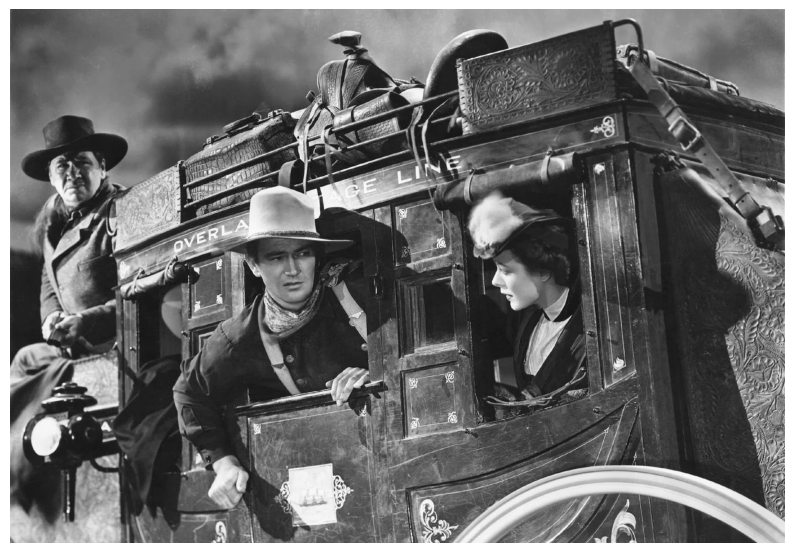

Detected 10 object(s):
- Clothing (Confidence: 80.41%)
- Fedora (Confidence: 76.55%)
- Clothing (Confidence: 76.50%)
- Hat (Confidence: 70.21%)
- Clothing (Confidence: 67.46%)
- Sun hat (Confidence: 67.09%)
- Person (Confidence: 66.52%)
- Person (Confidence: 66.17%)
- Person (Confidence: 66.08%)
- Fedora (Confidence: 63.93%)


In [ ]:
import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
# Ensure 'renaissance-ocr-4aabe5b8dc65.json' is uploaded to the /content/ folder
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def localize_stagecoach_objects(image_url):
    local_filename = "stagecoach_objects.jpg"

    # 3. Comprehensive headers to bypass 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Referer': 'https://commons.wikimedia.org'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=20)
        response.raise_for_status()
        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image downloaded for localization.")
    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(10, 7))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Perform Object Localization
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    # Using object_localization specifically
    response = client.object_localization(image=image)
    objects = response.localized_object_annotations

    print(f"Detected {len(objects)} object(s):")
    if not objects:
        print("No specific objects localized.")
    else:
        for obj in objects:
            print(f"- {obj.name} (Confidence: {obj.score:.2%})")
            # The API also provides 'obj.bounding_poly' for drawing boxes if needed

# 6. DIRECT URL: This points to the actual .jpg file
# Corrected path to the Stagecoach file on Wikimedia servers
stagecoach_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"

# Run the analysis
localize_stagecoach_objects(stagecoach_url)


In [ ]:
# Robot Art Historian Pipeline
#Producing a pipeline to automate Panofsky's three levels of iconography?

In [ ]:
#.Pre-Iconographical Description (Primary Matter)

Success: Binary image data secured as paumgartner_altarpiece.jpg.

--- LEVEL 1: EMPIRICAL VISUAL EVIDENCE ---


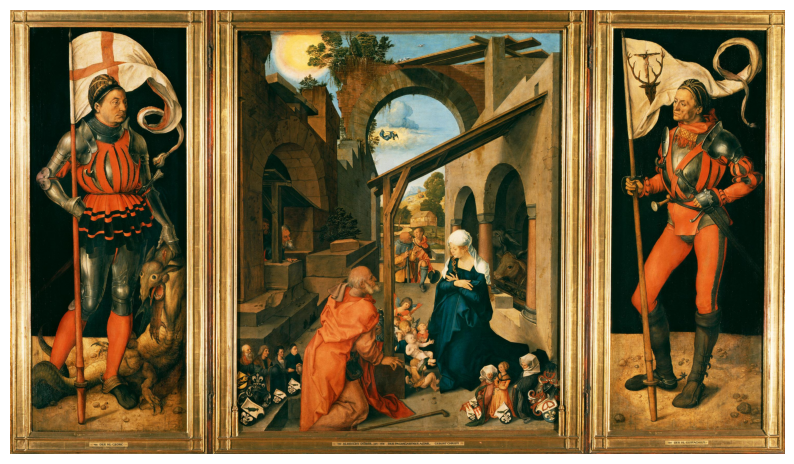


--- MACHINE-IDENTIFIED METADATA (WITH CONFIDENCE) ---
{
    "source_file": "paumgartner_altarpiece.jpg",
    "labels": [
        {
            "description": "Art",
            "confidence": 0.913
        },
        {
            "description": "Visual arts",
            "confidence": 0.907
        },
        {
            "description": "Painting",
            "confidence": 0.88
        },
        {
            "description": "Mythology",
            "confidence": 0.806
        },
        {
            "description": "Modern art",
            "confidence": 0.723
        },
        {
            "description": "Fictional character",
            "confidence": 0.689
        },
        {
            "description": "Prophet",
            "confidence": 0.629
        },
        {
            "description": "Middle Ages",
            "confidence": 0.626
        },
        {
            "description": "Picture frame",
            "confidence": 0.575
        }
    ],
    "objects": [
        {

In [ ]:
import os
import io
import json
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# Initialize the Vision client globally to avoid reconnecting on every loop
client = vision.ImageAnnotatorClient()

# CHANGED: Added 'local_filename' as a parameter instead of hardcoding it.
# In Section 5 (Working with External Data), batch processing requires dynamic file naming.
def get_level_1_data(image_url, local_filename="paumgartner_altarpiece.jpg"):

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
    }

    # 1. Data Acquisition
    try:
        resp = requests.get(image_url, headers=headers, timeout=20)
        resp.raise_for_status()
        with open(local_filename, 'wb') as f:
            f.write(resp.content)
        print(f"Success: Binary image data secured as {local_filename}.")
    except Exception as e:
        print(f"Data acquisition failed: {e}")
        return None

    # 2. Visual Rendering (DVT)
    img_array = dvt.load_image(local_filename)
    print("\n--- LEVEL 1: EMPIRICAL VISUAL EVIDENCE ---")
    plt.figure(figsize=(10, 6)) # CHANGED: Slightly smaller figure for Colab optimization
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 3. Machine Extraction (Google Vision)
    with io.open(local_filename, 'rb') as f:
        content = f.read()
    image = vision.Image(content=content)

    # Run detections
    labels_res = client.label_detection(image=image).label_annotations
    objects_res = client.object_localization(image=image).localized_object_annotations
    props_res = client.image_properties(image=image).image_properties_annotation
    text_res = client.text_detection(image=image).text_annotations

    # CHANGED: Added face detection.
    # Panofsky's 'Primary Matter' includes identifying human forms.
    # This prepares the data for advanced gesture/emotion analysis later.
    faces_res = client.face_detection(image=image).face_annotations

    # 4. Format metadata structurally (Dictionaries instead of simple strings)
    # CHANGED: We now capture the 'score' (confidence level) alongside the description.
    # In Distant Viewing, knowing the AI is only 45% confident in an object prevents historical misinterpretation.
    labels = [{"description": l.description, "confidence": round(l.score, 3)} for l in labels_res]

    objects = [{"name": o.name, "confidence": round(o.score, 3)} for o in objects_res]

    ocr_text = text_res[0].description.strip() if text_res else "No text detected."

    # CHANGED: Included 'pixel_fraction' alongside RGB.
    # For Light/Color Analysis across centuries, knowing an image is 60% dark brown vs 5% dark brown is vital empirical data.
    colors = []
    if props_res.dominant_colors.colors:
        for c in props_res.dominant_colors.colors[:5]: # CHANGED: Expanded to top 5 colors for a better palette footprint.
            r, g, b = int(c.color.red), int(c.color.green), int(c.color.blue)
            colors.append({
                "rgb": f"RGB({r}, {g}, {b})",
                "fraction": round(c.pixel_fraction, 3)
            })

    # CHANGED: Compile all findings into a single structured dictionary.
    # This allows you to easily dump the result into a MongoDB or JSON file for Cross-Cultural Analytics.
    structured_metadata = {
        "source_file": local_filename,
        "labels": labels,
        "objects": objects,
        "dominant_colors": colors,
        "ocr_text": ocr_text,
        "face_count": len(faces_res)
    }

    # 5. Print identified results for human verification
    print("\n--- MACHINE-IDENTIFIED METADATA (WITH CONFIDENCE) ---")
    print(json.dumps(structured_metadata, indent=4, ensure_ascii=False))

    return structured_metadata

# Execute Level 1
paumgartner_url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Albrecht_D%C3%BCrer%2C_Paumgartner_Altarpiece%2C_c1500%2C_Alte_Pinakothek%2C_Munich_%28702%29.jpg"

# CHANGED: Receives a single dictionary rather than multiple loose variables.
l1_data = get_level_1_data(paumgartner_url, "paumgartner_altarpiece.jpg")

In [ ]:
#Iconographical Analysis (Secondary Meaning)

In [ ]:
import json
from openai import OpenAI
from google.colab import userdata

# Securely fetch the key from Colab Secrets
DEEPSEEK_API_KEY = userdata.get('DEEPSEEK_API_KEY')
client_ds = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com")

# CHANGED: The function now accepts the comprehensive 'structured_metadata' dictionary from Level 1.
# Distant Viewing requires analyzing the confidence scores, not just the label names.
def get_level_2_blind_analysis(metadata):

    # CHANGED: We dynamically format the metadata to include confidence scores for the LLM.
    # An art historian needs to know if the machine is 99% sure it sees "Armor" or only 45% sure.
    labels_str = ", ".join([f"{l['description']} ({l['confidence']})" for l in metadata.get('labels', [])])
    objects_str = ", ".join([f"{o['name']} ({o['confidence']})" for o in metadata.get('objects', [])])
    colors_str = ", ".join([f"{c['rgb']} ({c['fraction'] * 100:.1f}%)" for c in metadata.get('dominant_colors', [])])
    ocr_text = metadata.get('ocr_text', 'None')

    # CHANGED: The prompt is rewritten to be dynamic and demand a JSON structure.
    # Hardcoding "Armor" and "Religious" assumes too much. The prompt must react to the actual data.
    # Returning JSON allows this data to be stored in the MongoDB database for Cross-Cultural Analytics.
    prompt = f"""
    Task: Blind Iconographical Identification (Panofsky Level 2).
    You are an expert digital art historian. Analyze this machine-extracted metadata from an UNKNOWN image.
    DO NOT guess the title. Analyze ONLY the empirical data provided.

    EMPIRICAL EVIDENCE:
    1. Labels (with confidence): {labels_str}
    2. Objects (with confidence): {objects_str}
    3. Palette (with pixel fraction): {colors_str}
    4. Detected Text: "{ocr_text}"

    INSTRUCTIONS:
    Provide your analysis strictly in JSON format using the following keys:
    - "stylistic_school": Deduced artistic period based on objects and palette.
    - "iconographic_intersection": How the top three most confident labels/objects interact to form a secondary meaning.
    - "textual_historical_link": Does the text suggest specific identities, donor functions, or cultural transmissions?
    - "semantic_gap_warning": Identify any low-confidence labels that might be machine hallucinations.
    """

    # CHANGED: Added temperature and response_format parameters.
    # A temperature of 0.2 reduces hallucination, ensuring a highly logical, empirical response.
    # The response_format parameter forces the DeepSeek model to return valid JSON.
    response = client_ds.chat.completions.create(
        model="deepseek-chat",
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": "You are a professional art historian practicing digital historiography. Output strictly in JSON format."},
            {"role": "user", "content": prompt}
        ]
    )

    # Extract and parse the JSON response
    analysis_raw = response.choices[0].message.content

    try:
        # CHANGED: Parse the string back into a Python dictionary.
        # This enables immediate integration with your quantitative datasets and graphing tools.
        analysis_dict = json.loads(analysis_raw)

        print(f"--- LEVEL 2: BLIND ICONOGRAPHICAL ANALYSIS (STRUCTURED) ---")
        print(json.dumps(analysis_dict, indent=4))

        return analysis_dict

    except json.JSONDecodeError:
        print("Error: The model did not return valid JSON.")
        return None

# Execute Level 2 using the structured dictionary from the improved Level 1 code
# NOTE: Ensure 'l1_data' is the dictionary returned from the improved get_level_1_data function.
if 'l1_data' in locals() and l1_data:
    l2_report = get_level_2_blind_analysis(l1_data)
else:
    print("Level 1 data not found. Please run the Level 1 extraction first.")


--- LEVEL 2: BLIND ICONOGRAPHICAL ANALYSIS (STRUCTURED) ---
{
    "stylistic_school": "Northern Renaissance, specifically German Renaissance, with strong medieval influences. The palette dominated by earthy browns (RGB(58,49,23), RGB(102,81,33), RGB(92,80,50)) and muted golds (RGB(181,150,94)) suggests the restrained, naturalistic color schemes of Northern European art from the late 15th to early 16th century. The presence of 'Picture frame' objects with high confidence indicates a multi-panel altarpiece structure typical of this period. The 'Middle Ages' label (0.626) aligns with the transitional period between medieval and Renaissance styles in Northern Europe.",
    "iconographic_intersection": "The intersection of 'Mythology' (0.806), 'Prophet' (0.629), and 'Painting' (0.88) suggests a religious narrative painting depicting saintly or prophetic figures within a mythological framework. This indicates the artwork likely portrays Christian saints (like St. George and St. Eustace menti

In [ ]:
# Level 3 Intrinsic meaning.

In [ ]:
import json
from openai import OpenAI
from google.colab import userdata

DEEPSEEK_API_KEY = userdata.get('DEEPSEEK_API_KEY')
client_ds = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com")

# CHANGED: The function now accepts the structured JSON dictionary from Level 2.
# Maintaining a continuous, machine-readable data pipeline prevents the re-introduction of the semantic gap.
def get_level_3_synthesis(iconography_json):

    # Format the incoming JSON for the LLM context
    context_str = json.dumps(iconography_json, indent=2)

    # CHANGED: Re-engineered the prompt to enforce Knowledge Graph extraction.
    # Panofsky's 'Intrinsic Meaning' must be quantifiable to avoid the pitfalls of traditional, subjective art history.
    # Generating Knowledge Graph edges prepares the data for multi-hop reasoning in a Cross-Cultural context.
    prompt = f"""
    Task: Deep Historiographical Synthesis (Iconology - Panofsky Level 3).

    Context from Level 2 Iconographical Analysis:
    {context_str}

    TASK: Provide an 'Iconological Reading' outputting STRICTLY as a JSON object.
    Map the intrinsic meaning of the artifact using the following keys:
    1. "zeitgeist_markers": Based on the empirical metadata, identify the cultural mentalité of the era.
    2. "patronage_dynamics": Analyze the socio-political implications of the identified donor portraiture.
    3. "epistemic_shift": Detail how these specific spatial hierarchies quantify the transition from medieval collective piety to Renaissance individualized patronage.
    4. "knowledge_graph_edges": Generate 3 to 5 Subject-Predicate-Object triples connecting this image's intrinsic meaning to broader historical themes (e.g., ["Donor Portraiture", "indicates", "Rise of Merchant Capitalism"]).
    """

    # CHANGED: Switched to deepseek-chat and added JSON response_format.
    # The 'reasoner' model often fails to return strict JSON.
    # For Distant Viewing pipelines, structural integrity is more critical than verbose philosophical generation.
    # CHANGED: Set temperature to 0.3.
    #Low temperature restricts hallucinations and grounds the iconological claims strictly in the provided metadata.
    response = client_ds.chat.completions.create(
        model="deepseek-chat",
        temperature=0.3,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": "You are a computational art historian. Ground iconological claims in empirical metadata. Output JSON only."},
            {"role": "user", "content": prompt}
        ]
    )

    synthesis_raw = response.choices[0].message.content

    try:
        # CHANGED: Parse the output into a dictionary.
        # This finalized data object can now be pushed directly to a MongoDB database to chart intertextuality and visual influence across cultures.
        synthesis_dict = json.loads(synthesis_raw)

        print(f"--- LEVEL 3: ICONOLOGICAL (DEEP) SYNTHESIS (STRUCTURED) ---")
        print(json.dumps(synthesis_dict, indent=4))
        return synthesis_dict

    except json.JSONDecodeError:
        print("Error: The model failed to bridge the semantic gap with valid JSON.")
        return None

# Execute Level 3 Synthesis
# NOTE: Ensure l2_report is the JSON dictionary returned from the optimized Level 2 function.
if 'l2_report' in locals() and l2_report:
    l3_data = get_level_3_synthesis(l2_report)
else:
    print("Level 2 data not found. Please run the Level 2 extraction first.")

--- LEVEL 3: ICONOLOGICAL (DEEP) SYNTHESIS (STRUCTURED) ---
{
    "zeitgeist_markers": "The artwork embodies the Northern Renaissance mentalit\u00e9 through its synthesis of medieval piety and emerging humanism. The earthy palette (RGB(58,49,23), RGB(102,81,33)) reflects Northern Europe's preference for naturalism over Italian idealism, while the multi-panel altarpiece structure maintains traditional devotional formats. The inclusion of both legendary saints (St. George, St. Eustace) and a Nativity scene demonstrates the era's continued reliance on religious narratives for moral instruction, yet D\u00fcrer's authorship (1471-1525) situates it within the German Renaissance's artistic awakening. The 'Mythology' label (0.806) intersecting with 'Prophet' (0.629) reveals how sacred stories were framed through quasi-mythological lenses, characteristic of transitional religious thought where faith coexisted with emerging empirical observation.",
    "patronage_dynamics": "The Paumgartner Alta


**Level 2 (Iconography)**

The code now feeds the AI the exact **confidence percentages** (e.g., 80% sure it is "mythology") and uses a setting to force the AI to reply in **JSON** (a structured data format).
The AI uses the OCR text to accurately identify the specific painting rather than guessing. It also uses the confidence scores to warn you if the machine is making a mistake (hallucinating), and the JSON format means you can instantly save the results to a database.

**Level 3 (Deep Historical Meaning)**
The code stops using the conversational "reasoner" and uses a strict JSON prompt that forces the AI to generate **Knowledge Graph edges** (Subject-Action-Target links).

It stops the AI from writing a subjective, fluffy art history essay. Instead, it turns complex historical meaning into hard, quantifiable data points that can be mathematically compared against thousands of other images for your Cross-Cultural Analytics project.